In [1]:
# !pip install astroquery

In [73]:
# Import necessary packages
from astroquery.esa.euclid.core import EuclidClass
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, ImageNormalize, PercentileInterval, AsinhStretch, LogStretch
plt.style.use(astropy_mpl_style)
from astropy.io import fits
import numpy as np
from astropy.table import Table
from astropy.wcs import WCS
import os

In [74]:
# choosing the archive envionment
# ['IDR', 'OTF', 'REG', 'PDR']
# Internal data release, the on-the-fly processing, the regression campaign,
# the public data release
Euclid = EuclidClass(environment='REG')

Fortunately there is no need to log-in if using the public Euclid data!

In [76]:
Euclid.login(user='cmurra01')

INFO: Login to Euclid TAP server: easreg.esac.esa.int:443/tap-server/tap/ [astroquery.esa.euclid.core]


Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid data service: easreg.esac.esa.int:443/sas-dd/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to Euclid cutout service: easreg.esac.esa.int:443/sas-cutout/tap-server/ [astroquery.esa.euclid.core]
INFO: OK [astroquery.utils.tap.core]


# The Cluster catalogue

This is the Euclid Q1 catalogue for the Euclid Deep Field South. The catalogue is joint match of clusters found by both of the Euclid cluster detection algorithms; PZWAV and AMICO. The catalogue contains the cluster positions, redshifts, richness (essentially the number of galaxies in the clusters) and a few other properties.

More information can be found in the Q1 article: https://arxiv.org/pdf/2503.19196

In [77]:
clusters = Table( fits.open('EUC_LE3_DET-CL_CL-DETECTIONS-PZWAV_20250526T104242.195573Z_03.20.fits')[1].data )

In [78]:
len( clusters )

590

In [79]:
clusters[:5]

ID_CLUSTER,RIGHT_ASCENSION_CLUSTER,DECLINATION_CLUSTER,Z_CLUSTER,Z_ERR_CLUSTER,SNR_CLUSTER,SNR_UNIQUE_CLUSTER,RADIUS_CLUSTER,RICHNESS_CLUSTER,LAMBDA_STAR_CLUSTER,FLAG_EDGE_CLUSTER,FRAC_MASKED_CLUSTER
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32
0,73.63256454047226,-35.96919628201458,2.3482897,0.12523955,29.72871,22.234404,0.19544101,22.234404,0.0,1.0,0.0
1,75.50532260408413,-34.890369019549446,0.8607382,0.20365593,29.591969,22.113817,0.11283792,22.113817,0.0,1.0,0.0
2,76.18590237318759,-27.990207123036026,0.57489574,0.1297686,28.406725,22.041344,1.1113245,22.041344,0.0,1.0,0.0
3,71.29551395274227,-34.020150431075166,1.3101788,0.0894917,28.680552,21.219984,1.339876,21.219984,0.0,0.0,0.0
4,70.37180891923505,-35.884539445651974,0.9346571,0.16331401,26.254421,20.012318,1.354055,20.012318,0.0,0.0,0.0


Text(0, 0.5, 'Declination')

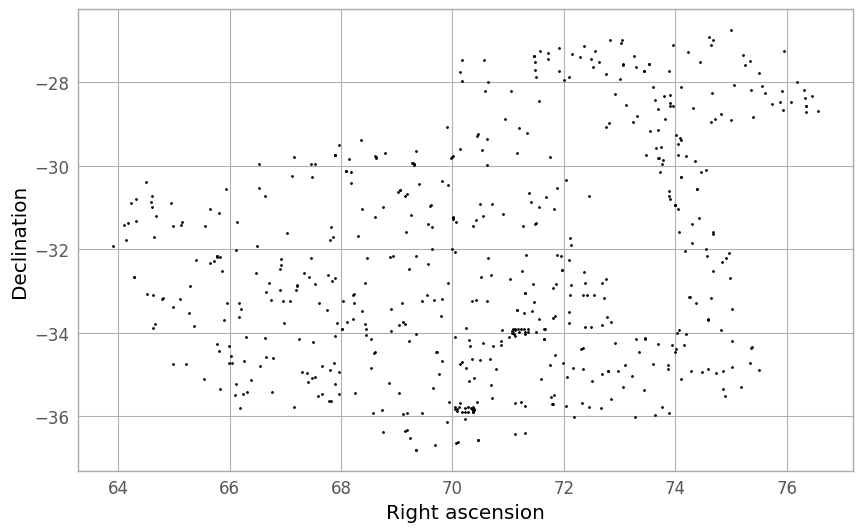

In [80]:
plt.figure( figsize = ( 10 , 6 ) )
plt.plot( clusters['RIGHT_ASCENSION_CLUSTER'] ,
          clusters['DECLINATION_CLUSTER'] , 'ko' , ms = 1)
plt.xlabel('Right ascension')
plt.ylabel('Declination')

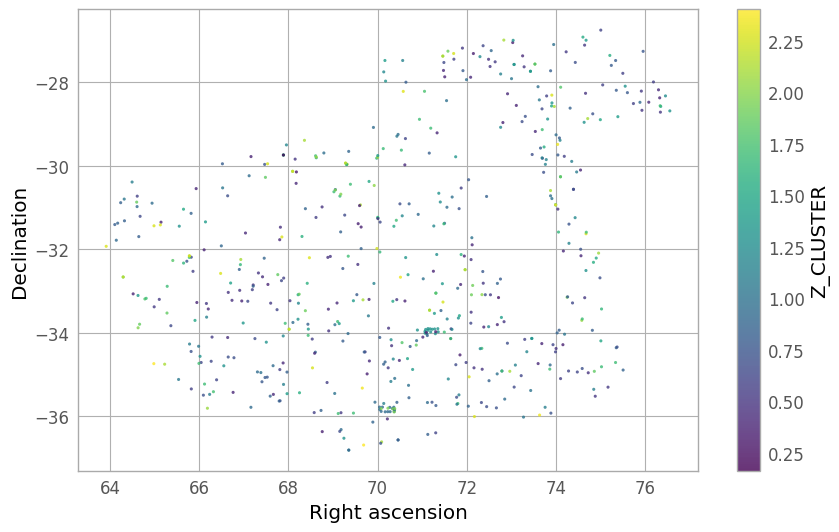

In [81]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    clusters['RIGHT_ASCENSION_CLUSTER'],
    clusters['DECLINATION_CLUSTER'],
    c=clusters['Z_CLUSTER'],
    cmap='viridis',    # or 'plasma', 'inferno', 'magma', etc.
    s=5,               # marker size
    alpha=0.8,
    edgecolors='none'
)
plt.xlabel('Right ascension')
plt.ylabel('Declination')
plt.colorbar(sc, label='Z_CLUSTER')  # adds a color bar to show the scale

# Querying the Euclid SAS

We can directly query the data, through a notebook using astroquery.

Let's start with a cluster I know is beautiful and the richest cluster found in Euclid so far: SPT-CL J0411-4819

In [82]:
clusters[:20]

ID_CLUSTER,RIGHT_ASCENSION_CLUSTER,DECLINATION_CLUSTER,Z_CLUSTER,Z_ERR_CLUSTER,SNR_CLUSTER,SNR_UNIQUE_CLUSTER,RADIUS_CLUSTER,RICHNESS_CLUSTER,LAMBDA_STAR_CLUSTER,FLAG_EDGE_CLUSTER,FRAC_MASKED_CLUSTER
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32
0,73.63256454047226,-35.96919628201458,2.3482897,0.12523955,29.72871,22.234404,0.19544101,22.234404,0.0,1.0,0.0
1,75.50532260408413,-34.890369019549446,0.8607382,0.20365593,29.591969,22.113817,0.11283792,22.113817,0.0,1.0,0.0
2,76.18590237318759,-27.990207123036026,0.57489574,0.1297686,28.406725,22.041344,1.1113245,22.041344,0.0,1.0,0.0
3,71.29551395274227,-34.020150431075166,1.3101788,0.0894917,28.680552,21.219984,1.339876,21.219984,0.0,0.0,0.0
4,70.37180891923505,-35.884539445651974,0.9346571,0.16331401,26.254421,20.012318,1.354055,20.012318,0.0,0.0,0.0
5,70.09014160806528,-36.611557066920234,2.1038601,0.12275062,25.906296,19.847496,0.25231326,19.847496,0.0,1.0,0.0
6,70.34233265159867,-33.24373324637267,1.4999967,0.107622385,25.787699,19.617567,0.35682482,19.617567,0.0,1.0,0.0
7,70.36353080853719,-35.78114578130614,0.93378615,0.19251557,25.057325,19.276958,1.6195288,19.276958,0.0,0.0,0.0
8,73.93337047282506,-34.28338735398773,0.62365746,0.09363947,24.208672,19.191591,1.4272993,19.191591,0.0,0.0,0.0


In [83]:
cluster_id = 4

In [84]:
clusters[ clusters['ID_CLUSTER'] == cluster_id]['RIGHT_ASCENSION_CLUSTER','DECLINATION_CLUSTER', 'Z_CLUSTER' , 'SNR_CLUSTER']

RIGHT_ASCENSION_CLUSTER,DECLINATION_CLUSTER,Z_CLUSTER,SNR_CLUSTER
float64,float64,float32,float32
70.37180891923505,-35.884539445651974,0.9346571,26.254421


In [85]:
ra_cluster = clusters[ clusters['ID_CLUSTER'] == cluster_id]['RIGHT_ASCENSION_CLUSTER'].value[0]
dec_cluster = clusters[ clusters['ID_CLUSTER'] == cluster_id]['DECLINATION_CLUSTER'].value[0]
z_cluster = clusters[ clusters['ID_CLUSTER'] == cluster_id]['Z_CLUSTER'].value[0]

In [90]:
# find images
coord = SkyCoord( ra_cluster , dec_cluster, frame='icrs' , unit ='deg')
radius = u.Quantity( 0.5 , u.deg)
j = Euclid.cone_search(
    coordinate=coord, 
    radius=radius, 
    table_name="sedm.mosaic_product", 
    ra_column_name="ra", 
    dec_column_name="dec", 
    columns="*", async_job=True)

cone_results = j.get_results()
print("Found", len(cone_results), "results")

INFO: Query finished. [astroquery.utils.tap.core]
Found 40 results


In [91]:
cone_results['file_path']

/euclid/repository_reg/reproc1_r1/REGREPROC1_R2/MER/102033826/NISP
/euclid/repository_reg/reproc1_r1/REGREPROC1_R2/MER/102033826/VIS
/euclid/repository_reg/reproc1_r1/REGREPROC1_R2/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/VIS
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP
/euclid/repository_reg/reproc1_r1/REGREPROC1_R2/MER/102033826/NISP
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP


In [95]:
mask = (
        ( np.char.find(cone_results['file_path'].astype(str), 'REGREPROC2') >= 0)
    )


In [97]:
cone_results[mask]['file_path']

/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/VIS
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033827/DECAM
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033827/NISP
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033827/VIS


In [98]:
current_folder = os.path.basename(os.getcwd())
print( current_folder )

colours_cluster_tutorial


In [99]:
# field of view in arcminutes
fov = 5

In [100]:
for filter_name in {"VIS", "NIR_H", "NIR_J", "NIR_Y", "DECAM_g", "DECAM_r" , "DECAM_i"}:
    print( filter_name )
    # select the reg2 product
    mask = (
            ( cone_results['filter_name'] == filter_name ) &
            ( np.char.find(cone_results['file_path'].astype(str), 'REGREPROC2') >= 0)
        )

    if len( cone_results[ mask ] )  > 0:
        example_file = cone_results[mask][0]

        print( example_file["file_path"] + "/" + example_file["file_name"] )

        # get it for VIS, NISP, DES
        # getting the arguments from the cone search result table automatically
        saved_cutout_filepath = Euclid.get_cutout(
            file_path=example_file["file_path"] + "/" + example_file["file_name"],
            instrument=example_file["instrument_name"],
            id=example_file["tile_index"],
            coordinate=coord,
            radius= fov * u.arcmin,
            output_file=f'cutouts/{cluster_id}_{filter_name}.fits' )


DECAM_g
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM/EUC_MER_BGSUB-MOSAIC-DES-G_TILE102033826-A40DB6_20250305T151210.092540Z_00.00.fits
NIR_J
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP/EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102033826-AF063A_20250305T152115.122052Z_00.00.fits
VIS
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102033826-D618B1_20250305T160451.589331Z_00.00.fits
NIR_Y
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102033826-C6D626_20250305T152116.544047Z_00.00.fits
DECAM_i
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/DECAM/EUC_MER_BGSUB-MOSAIC-DES-I_TILE102033826-35EF2D_20250305T151214.502157Z_00.00.fits
NIR_H
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/MER/102033826/NISP/EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102033826-D80813_20250305T152135.304326Z_00.00.fits
DECAM_r
/euclid/repository_reg//reproc1_r3/REGREPROC2_R1/

In [101]:
def get_images( red_file_name , green_file_name , blue_file_name  ):
    
    # we load the blue world-coordinate system, so we can correctly annotate the
    # image
    b_wcs = WCS( fits.open( blue_file_name )[0].header)
    b_cutout = fits.getdata( blue_file_name )
    g_cutout = fits.getdata( green_file_name)
    r_cutout = fits.getdata( red_file_name)
    
    return r_cutout, g_cutout, b_cutout , b_wcs

In [102]:
euclid_H_image, euclid_J_image, euclid_VIS_image, euclid_VIS_wcs = get_images( f'cutouts/{cluster_id}_NIR_H.fits' , 
                                                                               f'cutouts/{cluster_id}_NIR_J.fits' , 
                                                                               f'cutouts/{cluster_id}_VIS.fits')

We scale the pixel values to make reasonable scale images.

In [103]:
# Modify the percentile interval value and try different values for clipping or different stretches like SqrtStretch(), LogStretch()
transform = AsinhStretch() + PercentileInterval(99.5)
transform_alt = AsinhStretch() + PercentileInterval(99.7)

In [104]:
r_scaled = transform( euclid_H_image )
g_scaled = transform( euclid_J_image )
b_scaled = transform_alt( euclid_VIS_image )

In [105]:
np.min( r_scaled.flatten() ), np.max( r_scaled.flatten() )

(0.0, 0.99999994)

In [106]:
np.min( g_scaled.flatten() ), np.max( g_scaled.flatten() )

(0.0, 0.99999994)

In [107]:
np.min( b_scaled.flatten() ), np.max( b_scaled.flatten() )

(0.0, 0.99999994)

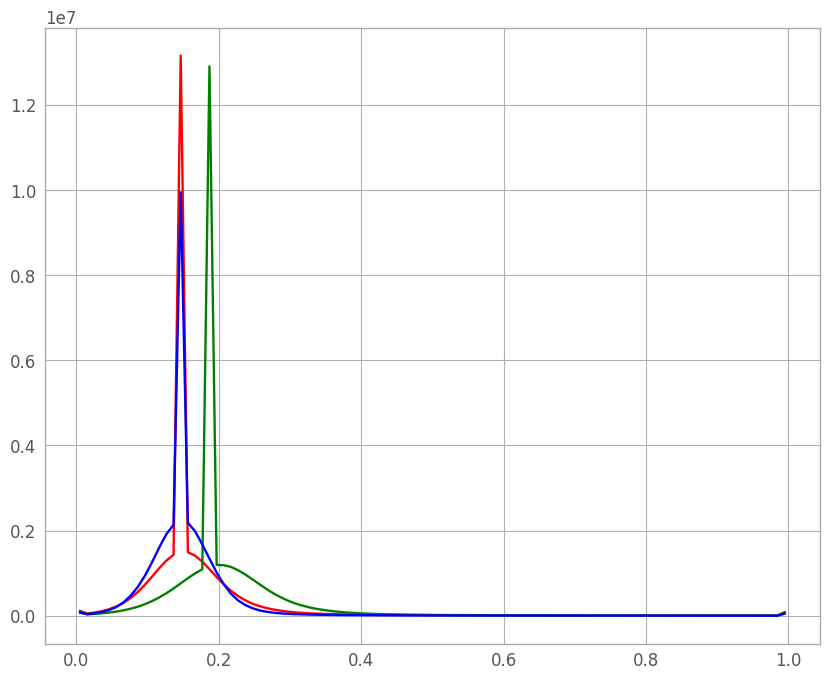

In [108]:
pixel_value_bins = np.linspace( 0 , 1 , 100 )
pixel_value_cents = ( pixel_value_bins[1:] + pixel_value_bins[:-1] )/2.

r_counts, _ = np.histogram( r_scaled , bins = pixel_value_bins )
g_counts, _ = np.histogram( g_scaled , bins = pixel_value_bins )
b_counts, _ = np.histogram( b_scaled , bins = pixel_value_bins )

plt.figure( figsize = ( 10 , 8 ) )
plt.plot( pixel_value_cents , r_counts , 'r' )
plt.plot( pixel_value_cents , g_counts , 'g' )
plt.plot( pixel_value_cents , b_counts , 'b' )

You should adjust these histograms accordingly, so that colours overlap. Try changing the clipping or a different stretch.

In [109]:
euclid_image = np.dstack([ r_scaled , g_scaled , b_scaled ])

In [110]:
pzwav_pixel_positions = euclid_VIS_wcs.world_to_pixel_values( clusters['RIGHT_ASCENSION_CLUSTER'] ,
                                                              clusters['DECLINATION_CLUSTER'] )

In [114]:
xlow = euclid_VIS_wcs.world_to_pixel_values( ra_cluster - fov / 60 , dec_cluster )[0]
xhig = euclid_VIS_wcs.world_to_pixel_values( ra_cluster + fov / 60 , dec_cluster )[0]
ylow = euclid_VIS_wcs.world_to_pixel_values( ra_cluster , dec_cluster + fov / 60 )[1]
yhig = euclid_VIS_wcs.world_to_pixel_values( ra_cluster , dec_cluster - fov / 60 )[1]


In [115]:
# xlow = euclid_VIS_wcs.world_to_pixel_values( 70.3 , -36 )[0]
# xhig = euclid_VIS_wcs.world_to_pixel_values( 70.6 , -36 )[0]
# ylow = euclid_VIS_wcs.world_to_pixel_values( 70.3 , -36.08)[1]
# yhig = euclid_VIS_wcs.world_to_pixel_values( 70.3 , -35.78)[1]

In [ ]:
fig = plt.figure( figsize=( 32,  32 ) , dpi = 300 )  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection = euclid_VIS_wcs )

ax.imshow( euclid_image , origin='lower')
ax.set_title('Euclid VIS-YH Image')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)
# ax.scatter( pzwav_pixel_positions[0], pzwav_pixel_positions[1],
#                color='r', marker='o', s=10, alpha=1)

# ax.set_xlim( xlow , xhig )
# ax.set_ylim( ylow , yhig )

ax.coords[0].set_major_formatter('d.ddd')
ax.coords[1].set_major_formatter('d.ddd')
# sometimes it does not display properly, so we can save and look at the png
plt.savefig('euclid_cluster.png')

In [ ]:
DECAM_g_image, DECAM_i_image, DECAM_r_image, DECAM_g_wcs = get_images( f'cutouts/{cluster_id}_DECAM_g.fits' , 
                                                                       f'cutouts/{cluster_id}_DECAM_i.fits' , 
                                                                       f'cutouts/{cluster_id}_DECAM_r.fits')

In [59]:
des_r_scaled = transform( DECAM_g_image )
des_g_scaled = transform( DECAM_i_image )
des_b_scaled = transform( DECAM_r_image )

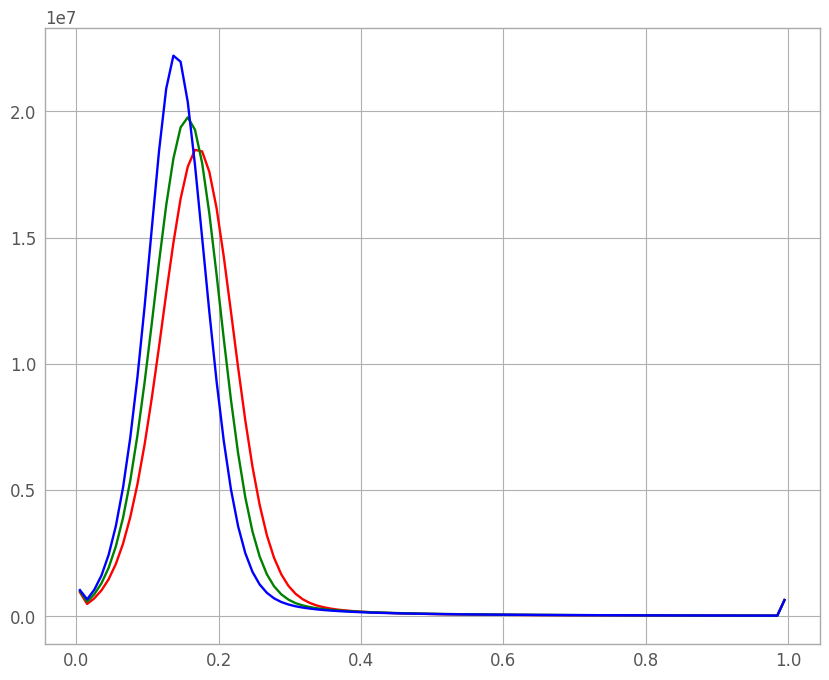

In [60]:
pixel_value_bins = np.linspace( 0 , 1 , 100 )
pixel_value_cents = ( pixel_value_bins[1:] + pixel_value_bins[:-1] )/2.

r_counts, _ = np.histogram( des_r_scaled , bins = pixel_value_bins )
g_counts, _ = np.histogram( des_g_scaled , bins = pixel_value_bins )
b_counts, _ = np.histogram( des_b_scaled , bins = pixel_value_bins )

plt.figure( figsize = ( 10 , 8 ) )
plt.plot( pixel_value_cents , r_counts , 'r' )
plt.plot( pixel_value_cents , g_counts , 'g' )
plt.plot( pixel_value_cents , b_counts , 'b' )

In [61]:
des_image = np.dstack([ des_r_scaled , des_g_scaled , des_b_scaled ])

In [62]:
des_pzwav_pixel_positions = DECAM_g_wcs.world_to_pixel_values( clusters['RIGHT_ASCENSION_CLUSTER'] ,
                                                                  clusters['DECLINATION_CLUSTER'] )

In [ ]:
fig = plt.figure(figsize=( 32,  32 ) , dpi = 300 )  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection = DECAM_g_wcs )

ax.imshow( des_image , origin='lower')
ax.set_title('Euclid VIS-YH Image')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)
ax.scatter( des_pzwav_pixel_positions[0], des_pzwav_pixel_positions[1],
               color='b', marker='o', s=10, alpha=1)
# xlow = DECAM_g_wcs.world_to_pixel_values( ra_cluster - fov / 60 , dec_cluster )[0]
# xhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster + fov / 60 , dec_cluster )[0]
# ylow = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster - fov / 60 )[1]
# yhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster + fov / 60 )[1]
ax.set_xlim( xlow , xhig )
ax.set_ylim( ylow , yhig )

ax.coords[0].set_major_formatter('d.ddd')
ax.coords[1].set_major_formatter('d.ddd')
# sometimes it does not display properly, so we can save and look at the png
plt.savefig('des_cluster.png')

In [ ]:
fig = plt.figure(figsize=( 32,  32 ) , dpi = 300 )  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection = DECAM_g_wcs )

ax.imshow( des_g_scaled , origin='lower', cmap='gray')
ax.set_title('Euclid VIS-YH Image')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)
ax.scatter( des_pzwav_pixel_positions[0], des_pzwav_pixel_positions[1],
               color='b', marker='o', s=10, alpha=1)
# xlow = DECAM_g_wcs.world_to_pixel_values( ra_cluster - fov / 60 , dec_cluster )[0]
# xhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster + fov / 60 , dec_cluster )[0]
# ylow = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster - fov / 60 )[1]
# yhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster + fov / 60 )[1]
ax.set_xlim( xlow , xhig )
ax.set_ylim( ylow , yhig )

ax.coords[0].set_major_formatter('d.ddd')
ax.coords[1].set_major_formatter('d.ddd')
# sometimes it does not display properly, so we can save and look at the png
plt.savefig('des_g_cluster.png')

In [ ]:
fig = plt.figure(figsize=( 32,  32 ) , dpi = 300 )  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection = DECAM_g_wcs )

ax.imshow( des_r_scaled , origin='lower', cmap='gray')
ax.set_title('Euclid VIS-YH Image')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)
ax.scatter( des_pzwav_pixel_positions[0], des_pzwav_pixel_positions[1],
               color='b', marker='o', s=10, alpha=1)
# xlow = DECAM_g_wcs.world_to_pixel_values( ra_cluster - fov / 60 , dec_cluster )[0]
# xhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster + fov / 60 , dec_cluster )[0]
# ylow = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster - fov / 60 )[1]
# yhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster + fov / 60 )[1]
ax.set_xlim( xlow , xhig )
ax.set_ylim( ylow , yhig )

ax.coords[0].set_major_formatter('d.ddd')
ax.coords[1].set_major_formatter('d.ddd')
# sometimes it does not display properly, so we can save and look at the png
plt.savefig('des_r_cluster.png')

In [ ]:
fig = plt.figure(figsize=( 32,  32 ) , dpi = 300 )  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection = DECAM_g_wcs )

ax.imshow( des_b_scaled , origin='lower', cmap='gray')
ax.set_title('DECAM-r')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)
ax.scatter( des_pzwav_pixel_positions[0], des_pzwav_pixel_positions[1],
               color='b', marker='o', s=10, alpha=1)
# xlow = DECAM_g_wcs.world_to_pixel_values( ra_cluster - fov / 60 , dec_cluster )[0]
# xhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster + fov / 60 , dec_cluster )[0]
# ylow = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster - fov / 60 )[1]
# yhig = DECAM_g_wcs.world_to_pixel_values( ra_cluster , dec_cluster + fov / 60 )[1]
ax.set_xlim( xlow , xhig )
ax.set_ylim( ylow , yhig )

ax.coords[0].set_major_formatter('d.ddd')
ax.coords[1].set_major_formatter('d.ddd')
# sometimes it does not display properly, so we can save and look at the png
plt.savefig('des_b_cluster.png')

In [51]:
job = Euclid.launch_job(
    "SELECT "
    "mer.right_ascension, "
    "mer.declination, "
    "phz.object_id, "
    "phz.flux_vis_unif, "
    "phz.flux_h_unif, "
    "phz.flux_y_unif, "
    "phz.flux_j_unif, "
    "phz.fluxerr_vis_unif, "
    "phz.fluxerr_h_unif, "
    "phz.fluxerr_y_unif, "
    "phz.fluxerr_j_unif, "
    "phz.phz_median, "
    "phz.phz_weight, "
    "phz.phz_classification, "
    "mer.ellipticity, "
    "mer.ellipticity_err, "
    "mer.position_angle, "
    "mer.position_angle_err, "
    "mer_morph.sersic_sersic_vis_index, "
    "mer_morph.sersic_sersic_nir_index, "
    "mer_morph.sersic_angle, "
    "mer_morph.sersic_sersic_vis_axis_ratio, "
    "mer_morph.sersic_sersic_nir_axis_ratio "
    "FROM catalogue.phz_photo_z AS phz "
    "JOIN catalogue.mer_catalogue AS mer ON mer.object_id = phz.object_id "
    "JOIN catalogue.mer_morphology AS mer_morph ON mer_morph.object_id = phz.object_id "
    "WHERE mer.point_like_prob < 0.95 "
    "AND phz.flux_h_unif > 0.912 "
    "AND phz.flux_h_unif IS NOT NULL "
    "AND mer.vis_det = 1 "
    "AND mer.flag_h != 3 "
    f"AND mer.declination > {dec_cluster - fov / 60  } AND mer.declination < {dec_cluster + fov / 60 } "
    f"AND mer.right_ascension > {ra_cluster - fov / 60  } AND mer.right_ascension < {ra_cluster + fov / 60 } "
    "AND phz.phz_median > 0 "
    "AND mer.det_quality_flag NOT IN (128, 256, 384);"
)

In [52]:
galaxies_in_field = job.get_results()
print( galaxies_in_field )

 right_ascension       declination     ... sersic_sersic_nir_axis_ratio
------------------ ------------------- ... ----------------------------
 62.83568910101621 -48.424265961723705 ...           0.4668242931365967
 62.78921622746191 -48.423162284300766 ...           0.7833137512207031
62.737387883025455 -48.423033043750486 ...          0.32763856649398804
 62.83106981754144  -48.42303135493886 ...          0.19249702990055084
 62.82827333922421  -48.42268902226951 ...           0.6067905426025391
 62.75755037701024  -48.42258146857189 ...          0.37700730562210083
62.749449609902484 -48.421666992845566 ...           0.6610273718833923
 62.81528277730709  -48.41995308124163 ...           0.9953729510307312
62.882946886121225 -48.419319656325776 ...          0.35568511486053467
 62.87211340384818 -48.418763000750644 ...           0.6489085555076599


In [53]:
len( galaxies_in_field )

868

In [54]:
galaxy_pixel_positions = euclid_VIS_wcs.world_to_pixel_values( galaxies_in_field['right_ascension'] ,
                                                               galaxies_in_field['declination'] )

In [ ]:
fig = plt.figure(figsize=( 16,  16 ))  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection = euclid_VIS_wcs )

ax.imshow( euclid_image , origin='lower')
ax.set_title('Euclid VIS-YH Image')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)
ax.scatter( galaxy_pixel_positions[0], galaxy_pixel_positions[1],
               color='r', marker='+', s=1, alpha=1)

plt.tight_layout()
# sometimes it does not display properly, so we can save and look at the png
plt.savefig('euclid_cluster.png')

In [ ]:
def make_rgb_image( red_file_name , blue_file_name , green_file_name ):
    """
    Simple code to create a colour image given a red, green and blue image
    channels
    """

    r_loc = f'{red_file_name}'
    g_loc = f'{green_file_name}'
    b_loc = f'{blue_file_name}'
    
    # we load the blue world-coordinate system, so we can correctly annotate the
    # image
    b_wcs = WCS( fits.open( b_loc )[0].header)
    b_cutout = fits.getdata( b_loc )
    g_cutout = fits.getdata( g_loc)
    r_cutout = fits.getdata( r_loc)

    # MODIFY HERE - Try different values for clipping or different stretches like SqrtStretch(), LogStretch()
    transform_b = AsinhStretch() + PercentileInterval(99.7)
    transform_rg = AsinhStretch() + PercentileInterval(99.5)

    b_scaled = transform_b(  b_cutout ) 
    g_scaled = transform_rg( g_cutout )
    r_scaled = transform_rg( r_cutout )

    temp = np.dstack([ r_scaled , g_scaled , b_scaled ])

    # house keeping, the might not even work...
    del b_cutout, g_cutout, r_cutout, b_scaled, g_scaled, r_scaled
    import gc; gc.collect()

    return temp , b_wcs

In [201]:
euclid_image, euclid_wcs = make_rgb_image( 'cutouts/0_NIR_H.fits' , 
                                           'cutouts/0_NIR_J.fits' , 
                                           'cutouts/0_VIS.fits')

In [ ]:
fig = plt.figure(figsize=( 16,  16 ))  # Adjust size as needed
ax = fig.add_subplot(1, 1, 1, projection=euclid_wcs)

ax.imshow( euclid_image , origin='lower')
ax.set_title('Euclid VIS-YH Image')
ax.set_xlabel('RA (degrees)', fontsize=15)
ax.set_ylabel('Dec (degrees)', fontsize=15)

plt.tight_layout()
# sometimes it does not display properly, so we can save and look at the png
# plt.savefig('euclid_cluster.png')

Try making a colour image from DECAM, see if Euclid is worthwhile! 